In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


df = pd.read_csv('cleaned_intakes_masked.csv')
df.shape

(639, 93)

In [2]:
df.head()

,PID,PID Match Basis,Summary,Issue key,Issue id,Issue Type,Status,Resolution,Reporter,Reporter Id,...,Custom field ([CHART] Date of First Response),Custom field ([CHART] Time in Status),Comment,Comment.1,Comment.2,Parent,Parent key,Parent summary,Status Category,Status Category Changed
0,P0289,Name + DOB,Person P0289,NEIG-19349,60769,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
1,P0352,Name + DOB,Person P0352,NEIG-19336,60756,New Profile,Second Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,2026-08-12 18:34:29.69,NaN,12/Aug/26 2:34 PM;712020:7919ac37-40c1-4b22-a8...,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
2,P0308,Name + DOB,Person P0308,NEIG-19324,60744,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
3,P0253,Name + DOB,Person P0253,NEIG-19311,60731,New Profile,Second Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,2026-08-11 19:11:08.805,NaN,11/Aug/26 3:11 PM;712020:7919ac37-40c1-4b22-a8...,NaN,NaN,NaN,NaN,NaN,In Progress,11/Aug/26 3:08 PM
4,P0102,Name + DOB,Person P0102,NEIG-19296,60716,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,11/Aug/26 3:08 PM


In [3]:
df.dtypes

PID                            str
PID Match Basis                str
Summary                        str
Issue key                      str
Issue id                     int64
                            ...   
Parent                     float64
Parent key                     str
Parent summary                 str
Status Category                str
Status Category Changed        str
Length: 93, dtype: object

TASK 0


In [4]:
df[['Issue key', 'Issue id', 'Created', 'PID', 'Issue Type', 'Parent key']].sort_values('Issue id').head(20)

,Issue key,Issue id,Created,PID,Issue Type,Parent key
638,NEIG-10695,35312,01/Jan/26 9:15 AM,P0337,New Profile,NaN
637,NEIG-10735,35478,05/Jan/26 1:53 PM,P0230,New Profile,NaN
636,NEIG-10748,35500,06/Jan/26 1:02 AM,P0114,New Profile,NaN
635,NEIG-10753,35509,06/Jan/26 1:44 AM,P0171,New Profile,NaN
634,NEIG-10757,35548,06/Jan/26 11:35 AM,P0183,New Profile,NaN
633,NEIG-10761,35555,06/Jan/26 12:26 PM,P0369,New Profile,NaN
632,NEIG-10769,35602,06/Jan/26 6:24 PM,P0177,New Profile,NaN
631,NEIG-10775,35613,06/Jan/26 8:25 PM,P0284,New Profile,NaN
630,NEIG-10811,35711,07/Jan/26 1:43 PM,P0130,New Profile,NaN
629,NEIG-10816,35720,07/Jan/26 3:08 PM,P0320,New Profile,NaN


1. What does the NEIG-##### ticket number actually represent?

The NEIG ticket number is an automatic incrementing counter for events in the system. Any time there is a action such as a new profile, the next number is given to that event. This is shown when the Issue ID increases the later the ticket was created. 

2. Why aren't ticket numbers sequential per family?


They are not sequential per family because it is not scoped to a person but to time. If a person were to create a ticket then multiple other people were to create a ticket, then that same person who created a ticket made another one for more help they would get what number is next in line at that time. This is shown with PID 0230 has their first ticket got  10735 but his second got 10889.

3. What does Issue Type tell you about new intakes vs. sub-tickets?


Issue type is two categories. New profile is a person first ever ticket. This will always have a empty Parent key. Any other issue type value is a sub ticket that shows an additional need for a person with a already exisiting profile. The sub ticket always has a parent key pointing back to the original new profile ticket

In [5]:
df.columns.tolist()

['PID',
 'PID Match Basis',
 'Summary',
 'Issue key',
 'Issue id',
 'Issue Type',
 'Status',
 'Resolution',
 'Reporter',
 'Reporter Id',
 'Creator',
 'Creator Id',
 'Created',
 'Updated',
 'Resolved',
 'Labels.1',
 'Labels.2',
 'Labels.3',
 'Labels.4',
 'Labels.5',
 'Labels.6',
 'Watchers',
 'Watchers.1',
 'Watchers Id',
 'Watchers Id.1',
 '# Additional Household Members',
 'Custom field (City)',
 'Custom field (Community Ministry)',
 'Custom field (Court Date)',
 'Custom field (Current Employer)',
 'Age at Intake',
 'Custom field (Employment Status)',
 'Custom field (Eviction Reason)',
 'Custom field (Eviction Status)',
 'Custom field (Gender)',
 'Custom field (Goals)',
 'Custom field (Goals).1',
 'Custom field (Goals).2',
 'Custom field (Goals).3',
 'Custom field (Household Identities)',
 'Custom field (Household Identities).1',
 'Custom field (Household repairs required?)',
 'Custom field (Housing Status)',
 'Custom field (Income Amount ($))',
 'Custom field (Insurance Provider for 

In [6]:
with open('column_profile.txt', 'w') as f:
    for col in df.columns:
        f.write(f"{col} | dtype: {df[col].dtype} | sample: {df[col].dropna().unique()[:5]}\n")

In [7]:
with open('columns.txt', 'w') as f:
    for i, col in enumerate(df.columns):
        f.write(f"{i} {col}\n")

| Column Name | Category | Reason |
|---|---|---|
| PID | Needed | Needed for repeat contracts|
| PID Match Basis | Drop | metadata not case data |
| Summary | Drop | Not household information just ticket summary |
| Issue key | Needed | Needed for task 0 and refrence tickets|
| Issue id | Drop | Redundant with Issue key |
| Issue Type | Needed | Distingushes intake stages|
| Status | Needed | Track case status|
| Resolution | Drop |Jira workflow field |
| Reporter | Drop |Jira staff field |
| Reporter Id | Drop |Jira staff field |
| Creator | Drop |Jira staff field |
| Creator Id | Drop |Jira staff field |
| Created | Needed | Ticket creation date needed from timeline analysis|
| Updated | Drop |Jira system timestamp no client situation |
| Resolved | Needed |Resolution date good for timeline analysis |
| Labels.1 | Optional | messy value field but contains tags |
| Labels.2 | Optional | messy value field but contains tags|
| Labels.3 | Optional | messy value field but contains tags|
| Labels.4 | Optional | messy value field but contains tags|
| Labels.5 | Optional | messy value field but contains tags|
| Labels.6 | Optional | messy value field but contains tags|
| Watchers | Drop | Jira notification no client data|
| Watchers.1 | Drop | Jira notification no client data|
| Watchers Id | Drop | Jira notification no client data|
| Watchers Id.1 | Drop | Jira notification no client data|
| # Additional Household Members | Needed | Needed for household composition question|
| Custom field (City) | Optional | Location context not needed for question but still usable|
| Custom field (Community Ministry) | Optional |What SLCM site handled the case. useful but not needed |
| Custom field (Court Date) | Optional | Adds context about evicition process but not needed|
| Custom field (Current Employer) | Optional |Employer detail thats not needed for employment status |
| Age at Intake | Needed | Needed for household and demographic breakdown|
| Custom field (Employment Status) | Needed | Needed for employment and income questions|
| Custom field (Eviction Reason) | Needed | Needed to assess housing crisis|
| Custom field (Eviction Status) | Needed | Needed to measure eviction risk|
| Custom field (Gender) | Optional | Demographic detail but not required|
| Custom field (Goals) | Optional | May indicate intent but not needed|
| Custom field (Goals).1 | Optional | May indicate intent but not needed|
| Custom field (Goals).2 | Optional | May indicate intent but not needed|
| Custom field (Goals).3 | Optional | May indicate intent but not needed|
| Custom field (Household Identities) | Optional | Demographic data but not needed|
| Custom field (Household Identities).1 | Optional | Demographic data but not needed|
| Custom field (Household repairs required?) | Optional | Adds context about housing quality but not needed|
| Custom field (Housing Status) | Needed | Core field of evicition risk and housing crisis|
| Custom field (Income Amount ($)) | Needed | Needed for employment vs income|
| Custom field (Insurance Provider for Family) | Optional | Gives context about heath but not needed|
| Custom field (Intake Date) | Optional | Useful for cross checking but not needed|
| Has LG&E Account on File | Needed | Utility analysis and finacial hardship|
| Custom field (Landlord Name) | Optional | Not needed for analysis|
| Custom field (Loss of Income Causation) | Optional | Adds context to employment and income questions but not needed|
| Custom field (Loss of Income Causation).1 | Optional | Adds context to employment and income questions but not needed|
| Custom field (Loss of Income Causation).2 | Optional | Adds context to employment and income questions but not needed |
| Custom field (Loss of Income Causation).3 | Optional | Adds context to employment and income questions but not needed |
| Custom field (Main reason Neighbor stopped paying rent) | Optional | Adds more context to housing crisis question|
| Custom field (Monthly Rent ($)) | Needed | Needed for housing crisis severity context|
| Has Email on File | Drop | Not about household situation|
| Has Phone on File | Drop | Not about household situation|
| Custom field (Other Professionals Detail) | Drop | Not client situation data|
| Custom field (Other professionals helping with goals?) | Drop | Not client situation data|
| Custom field (Past Due Rent ($)) | Needed | Needed for housing crisis|
| Custom field (People in Household 17 and Under) | Needed | Need for household compisition|
| Custom field (People in Household 18+) | Needed |Need for household compisition |
| Custom field (People in Household 65+) | Needed |Need for household compisition |
| Custom field (Preferred method of contact) | Drop |Not about household situation |
| Custom field (Preferred method of contact).1 | Drop |Not about household situation |
| Custom field (Primary Insurance) | Optional |Gives context based on heath but not needed |
| Custom field (Primary Language Spoken in Home) | Optional |Gives context based on demographic but not needed |
| Custom field (Pronoun) | Drop |Not relvant to house or case analysis |
| Custom field (Race/Ethnicity) | Optional |Demographic detail but not needed |
| Custom field (Rank) | Drop |jira board field |
| Custom field (Rent Intake Form Goals) | Optional |May indicate stage of need which could be useful|
| Custom field (Rent Intake Form Goals).1 | Optional |May indicate stage of need which could be useful |
| Custom field (Rent Intake Form Goals).2 | Optional |May indicate stage of need which could be useful |
| Custom field (Rent Intake Form Goals).3 | Optional |May indicate stage of need which could be useful |
| Custom field (Rent-to-Income %) | Needed |Measures rent burden needed for housing crisis |
| Custom field (Response Method) | Drop |contact not needed for housing situation |
| Custom field (Response Method).1 | Drop |contact not needed for housing situation |
| Custom field (Section 8 or Housing Voucher) | Optional |Housing assistance that adds context but not needed |
| Custom field (Source of income) | Needed |Needed for employment and income question |
| Custom field (Source of income).1 | Needed |Needed for employment and income question |
| Custom field (State) | Optional |Gives location context but not needed |
| Custom field (Utility Past Due) | Needed |Utility burden thats tied to financial hardship |
| Has Water Account on File | Needed |Utility linked to financial hardship |
| Custom field (Zip Code) | Needed |Needed for seeing if housing crisis differs by zip code |
| Custom field ([CHART] Date of First Response) | Drop |Not client data |
| Custom field ([CHART] Time in Status) | Drop |Not client data |
| Comment | Drop |Staff notes not client data |
| Comment.1 | Drop |Staff notes not client data |
| Comment.2 | Drop |Staff notes not client data |
| Parent | Needed |Needed to explaining ticket for task 0 |
| Parent key | Needed |Needed for task 0 |
| Parent summary | Drop |Not needed and has clients names |
| Status Category | Drop |Jira workflow |
| Status Category Changed | Drop |Jira workflow |

TASK 1

In [8]:
print(df['Issue Type'].unique())

<StringArray>
[                               'New Profile',
                             'Food Care Path',
                          'Utility Care Path',
                  'Rent Assistance Care Path',
                             'Basic Supplies',
                 'House Navigation Care Path',
 'Foreclosure Prevention/Mortgage Assistance',
                 'Legal Assistance Care Path',
              'Eviction Prevention Care Path',
                             'Digital Access',
                   'Transportation Care Path',
                            'Child Care Path',
                                      'Other',
                     'Medical Costs or Bills',
                 'Connected Neighbor Profile',
            'Case Management Navigation Path',
             'Pregnancy/Postpartum Care Path',
                                  'Care Plan',
 'Job Search/Workforce Development Care Path',
                   'Children's Welfare (CPS)',
                     'Play Cousins Care Path',

In [9]:
print(df['Status'].unique())

<StringArray>
[                        'Initial Contact',
                          'Second Contact',
           'External Org to Complete Goal',
                   'Goal No Longer Wanted',
                           'Goal Attained',
                           'Referral Only',
                               'Duplicate',
                               'Follow Up',
                       'Unable to Contact',
                          'Friction Point',
                   'Goal No Longer Needed',
                   'Connected to Resource',
                            'New Neighbor',
                   'Identifying Resources',
                                     'New',
 'Unable to Contact/Stopped Communication',
                                    'Open',
                             'Service Gap',
                       'Goals in Progress',
                    'Nav No Longer Wanted']
Length: 20, dtype: str


In [10]:
df[df['Issue Type'].isin(['Connected Neighbor Profile', 'Flourishing Neighbor Profile'])][['Issue key', 'Parent key', 'Status']]

,Issue key,Parent key,Status
237,NEIG-16319,NaN,New Neighbor
247,NEIG-16174,NaN,Identifying Resources
279,NEIG-15768,NaN,New Neighbor
315,NEIG-15215,NaN,New Neighbor
324,NEIG-15057,NaN,New Neighbor
347,NEIG-14793,NaN,Identifying Resources
361,NEIG-14608,NaN,New Neighbor
397,NEIG-14065,NaN,New Neighbor
406,NEIG-14006,NaN,New Neighbor
417,NEIG-13926,NaN,New Neighbor


In [11]:
reconnect = df[df['Parent key'].isna()]
rethink = df[df['Parent key'].notna()]

reconnect_stable = reconnect[reconnect['Custom field (Eviction Status)'].isin(['Not being evicted'])]
reconnect_risk = reconnect[reconnect['Custom field (Eviction Status)'].isin(['Currently being evicted', 'Received 7 day notice'])]

print("Reconnect total:", len(reconnect))
print("Reconnect - Housing stable:", len(reconnect_stable))
print("Reconnect - Eviction risk:", len(reconnect_risk))
print("Rethink total:", len(rethink))
print("Rebuild total: 0 (not tracked in this dataset)")

Reconnect total: 426
Reconnect - Housing stable: 255
Reconnect - Eviction risk: 108
Rethink total: 213
Rebuild total: 0 (not tracked in this dataset)


In [12]:
print(reconnect['Custom field (Eviction Status)'].value_counts(dropna=False))

Custom field (Eviction Status)
Not being evicted          255
Currently being evicted    106
Unknown                     63
Received 7 day notice        2
Name: count, dtype: int64


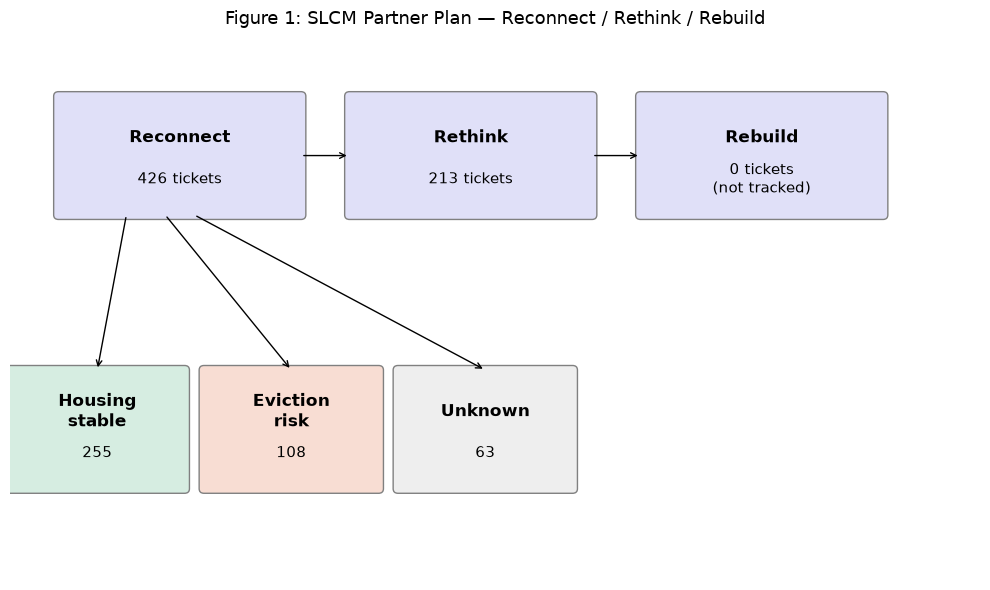

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

def box(x, y, w, h, title, count, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", facecolor=color, edgecolor='gray')
    ax.add_patch(rect)
    ax.text(x + w/2, y + h*0.65, title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(x + w/2, y + h*0.3, count, ha='center', va='center', fontsize=11)

box(0.5, 4, 2.5, 1.3, "Reconnect", "426 tickets", "#e0e0f8")
box(3.5, 4, 2.5, 1.3, "Rethink", "213 tickets", "#e0e0f8")
box(6.5, 4, 2.5, 1.3, "Rebuild", "0 tickets\n(not tracked)", "#e0e0f8")

box(0, 1, 1.8, 1.3, "Housing\nstable", "255", "#d6ede1")
box(2, 1, 1.8, 1.3, "Eviction\nrisk", "108", "#f8ddd3")
box(4, 1, 1.8, 1.3, "Unknown", "63", "#eeeeee")

ax.annotate('', xy=(3.5, 4.65), xytext=(3.0, 4.65), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(6.5, 4.65), xytext=(6.0, 4.65), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.9, 2.3), xytext=(1.2, 4.0), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(2.9, 2.3), xytext=(1.6, 4.0), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(4.9, 2.3), xytext=(1.9, 4.0), arrowprops=dict(arrowstyle='->'))

plt.title("Figure 1: SLCM Partner Plan — Reconnect / Rethink / Rebuild", fontsize=13)
plt.tight_layout()
plt.savefig('figure1.png', dpi=150)
plt.show()

In [14]:
print(df['Custom field (Housing Status)'].value_counts())

Custom field (Housing Status)
Rent- past due                                          234
Rent - nothing past due                                 126
Staying with friends/family                              29
Unhoused                                                 15
Other                                                    10
Own home - nothing past due                               5
Own home - mortgage past due                              4
Staying at extended stay hotel or short-term housing      3
Name: count, dtype: int64


In [15]:
pid_counts = df['PID'].value_counts()
df['ticket_frequency'] = df['PID'].map(pid_counts)
df['is_chronic'] = df['ticket_frequency'] >= 2

df['is_urgent'] = (
    (df['Custom field (Eviction Status)'] == 'Currently being evicted') |
    (df['Custom field (Housing Status)'] == 'Unhoused')
)

quadrant = pd.crosstab(df['is_chronic'], df['is_urgent'])
print(quadrant)

is_urgent   False  True 
is_chronic              
False         200     89
True          319     31


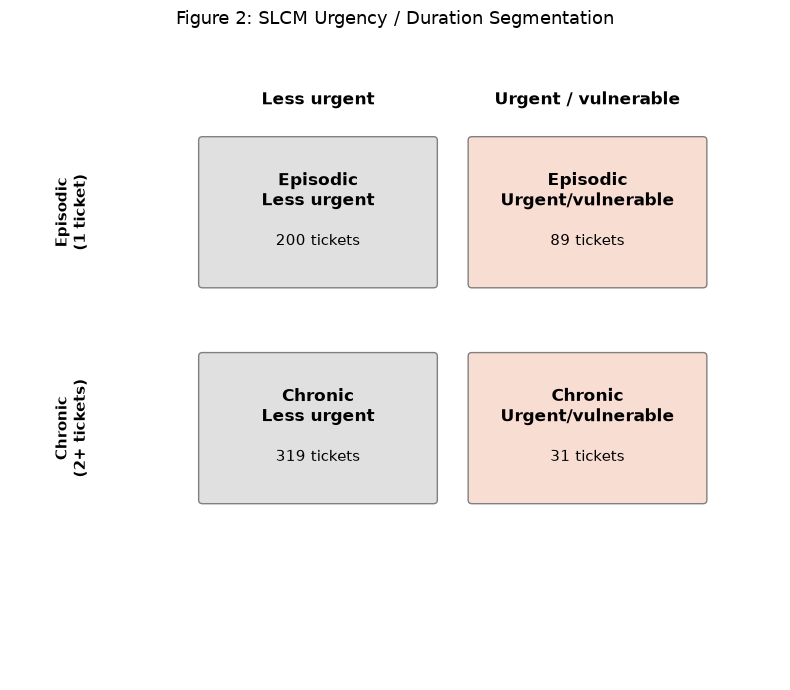

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 9)
ax.axis('off')

def box(x, y, w, h, title, count, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", facecolor=color, edgecolor='gray')
    ax.add_patch(rect)
    ax.text(x + w/2, y + h*0.65, title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(x + w/2, y + h*0.3, f"{count} tickets", ha='center', va='center', fontsize=11)

box(2.5, 5.5, 3, 2, "Episodic\nLess urgent", "200", "#e0e0e0")
box(6, 5.5, 3, 2, "Episodic\nUrgent/vulnerable", "89", "#f8ddd3")
box(2.5, 2.5, 3, 2, "Chronic\nLess urgent", "319", "#e0e0e0")
box(6, 2.5, 3, 2, "Chronic\nUrgent/vulnerable", "31", "#f8ddd3")

ax.text(0.8, 6.5, "Episodic\n(1 ticket)", ha='center', va='center', fontsize=11, fontweight='bold', rotation=90)
ax.text(0.8, 3.5, "Chronic\n(2+ tickets)", ha='center', va='center', fontsize=11, fontweight='bold', rotation=90)
ax.text(4, 8, "Less urgent", ha='center', fontsize=12, fontweight='bold')
ax.text(7.5, 8, "Urgent / vulnerable", ha='center', fontsize=12, fontweight='bold')

plt.title("Figure 2: SLCM Urgency / Duration Segmentation", fontsize=13)
plt.tight_layout()
plt.savefig('figure2.png', dpi=150)
plt.show()

Which parts of the partner's plan does this data NOT currently support, and what would you propose SLCM start collecting instead?

When looking through the data, we found none of the 93 columns explicitly track which stage the household is in. Instead, there was Issue Type that tracks what kind of help was requested and Status which tracked how it was going. We ruled out the Neighbor Profile types because it was just more root tickets and didn't help.They did not help because there was no parent ID and not a marker for a later stage. When working on figure 1, rebuild actually came back as 0 because there is nothing to count for rebuild. What we suggest is a dropdown field on each ticket for the current stage of that ticket.

TASK 2

In [17]:
dtypes = df.dtypes.reset_index()
dtypes.columns = ['Column Name', 'Dtype']
dtypes.to_csv('dtypes_check.csv', index=False)
print(dtypes.to_string())

                                                Column Name    Dtype
0                                                       PID      str
1                                           PID Match Basis      str
2                                                   Summary      str
3                                                 Issue key      str
4                                                  Issue id    int64
5                                                Issue Type      str
6                                                    Status      str
7                                                Resolution      str
8                                                  Reporter      str
9                                               Reporter Id      str
10                                                  Creator      str
11                                               Creator Id      str
12                                                  Created      str
13                                

In [18]:
numeric_cols = ['Age at Intake', 'Custom field (Income Amount ($))', 
                 'Custom field (Monthly Rent ($))', 'Custom field (Past Due Rent ($))', 
                 'Custom field (Rent-to-Income %)']
print(df[numeric_cols].describe())

       Age at Intake  Custom field (Income Amount ($))  \
count     426.000000                        426.000000   
mean       30.899061                       1681.958920   
std         8.018898                       5149.032095   
min        -1.000000                          0.000000   
25%        26.000000                          0.000000   
50%        30.000000                        907.000000   
75%        35.000000                       2000.000000   
max        71.000000                      75000.000000   

       Custom field (Monthly Rent ($))  Custom field (Past Due Rent ($))  \
count                       168.000000                        164.000000   
mean                       1799.127143                       3822.280671   
std                        9580.505883                      18865.749259   
min                           0.000000                          0.000000   
25%                         900.000000                       1118.750000   
50%                  

In [19]:
print(df[df['Age at Intake'] < 0][['PID', 'Age at Intake']])
print(df[df['Custom field (Monthly Rent ($))'] > 10000][['PID', 'Custom field (Monthly Rent ($))', 'Custom field (Income Amount ($))']])

       PID  Age at Intake
252  P0370           -1.0
       PID  Custom field (Monthly Rent ($))  Custom field (Income Amount ($))
634  P0183                         125100.0                               0.0


In [20]:
cols_to_check = ['PID', 'Custom field (Housing Status)', 'Custom field (City)', 
                  'Custom field (Zip Code)', 'Custom field (Income Amount ($))', 
                  'Custom field (Monthly Rent ($))', 'Custom field (Past Due Rent ($))',
                  '# Additional Household Members', 'Custom field (Landlord Name)']
print(df[df['PID'] == 'P0183'][cols_to_check])

       PID Custom field (Housing Status) Custom field (City)  \
608  P0183                           NaN                 NaN   
634  P0183                Rent- past due          Louisville   

    Custom field (Zip Code)  Custom field (Income Amount ($))  \
608                     NaN                               NaN   
634                   40202                               0.0   

     Custom field (Monthly Rent ($))  Custom field (Past Due Rent ($))  \
608                              NaN                               NaN   
634                         125100.0                          242682.0   

     # Additional Household Members Custom field (Landlord Name)  
608                               0                          NaN  
634                               0             Premium property  


In [21]:
print(df['Custom field (Monthly Rent ($))'].sort_values(ascending=False).head(15))

634    125100.00
343      3743.94
391      2000.00
86       1895.00
228      1780.00
609      1650.00
176      1600.00
122      1600.00
258      1600.00
426      1570.00
498      1560.00
326      1545.00
345      1545.00
431      1540.00
459      1535.00
Name: Custom field (Monthly Rent ($)), dtype: float64


In [22]:
print(df['Custom field (Past Due Rent ($))'].sort_values(ascending=False).head(15))

634    242682.00
609     16000.00
243      8000.00
233      7000.00
558      7000.00
555      7000.00
444      6965.00
636      6800.00
174      6500.00
426      5300.00
560      5033.28
539      5000.00
107      5000.00
145      5000.00
86       5000.00
Name: Custom field (Past Due Rent ($)), dtype: float64


In [23]:
cols_to_check = ['PID', 'Custom field (Housing Status)', 'Custom field (Income Amount ($))', 
                  'Custom field (Monthly Rent ($))', 'Custom field (Past Due Rent ($))',
                  '# Additional Household Members', 'Custom field (Landlord Name)']
print(df.loc[[609]][cols_to_check])

       PID Custom field (Housing Status)  Custom field (Income Amount ($))  \
609  P0178                Rent- past due                             900.0   

     Custom field (Monthly Rent ($))  Custom field (Past Due Rent ($))  \
609                           1650.0                           16000.0   

     # Additional Household Members Custom field (Landlord Name)  
609                               1                  Mary Loudry  


In [24]:
df.loc[df['Age at Intake'] < 0, 'Age at Intake'] = pd.NA
#It seems that if age is not listed it is set to -1. Made it just not avaliable

In [25]:
df.loc[df['PID'] == 'P0183', 'Custom field (Monthly Rent ($))'] = pd.NA
df.loc[df['PID'] == 'P0183', 'Custom field (Past Due Rent ($))'] = pd.NA
#  P0183: Monthly Rent and Past Due Rent appear to be off by about 100 times. He had a income of 0$ but a monthly rent of $125,100
# What also shows how this is an error is when looking into his ticket he has a zip code of 40202 and when looking the common rent in the area is between 1,000 and 2,000.


In [26]:
cat_cols = ['Custom field (Housing Status)', 'Custom field (Eviction Status)', 
            'Custom field (Employment Status)', 'Custom field (Source of income)',
            'Custom field (State)', 'Custom field (City)']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Custom field (Housing Status) ---
Custom field (Housing Status)
Rent- past due                                          234
NaN                                                     213
Rent - nothing past due                                 126
Staying with friends/family                              29
Unhoused                                                 15
Other                                                    10
Own home - nothing past due                               5
Own home - mortgage past due                              4
Staying at extended stay hotel or short-term housing      3
Name: count, dtype: int64

--- Custom field (Eviction Status) ---
Custom field (Eviction Status)
Not being evicted          255
NaN                        213
Currently being evicted    106
Unknown                     63
Received 7 day notice        2
Name: count, dtype: int64

--- Custom field (Employment Status) ---
Custom field (Employment Status)
NaN                                    

In [27]:
print(df['Custom field (Employment Status)'].value_counts(dropna=False))

Custom field (Employment Status)
NaN                                                    213
Unemployed but want to find work                       195
Employed                                               118
Employed, but need more hours and/or different work     57
Other                                                   29
Unemployed and not looking for work                     27
Name: count, dtype: int64


In [28]:
print(df['Custom field (Source of income)'].value_counts(dropna=False))

Custom field (Source of income)
NaN                           217
Food benefits - TANF/SNAP     178
Full-time employment           86
No income                      79
Part-time employment           38
Social Security - SSI/SSDI     22
Other                          16
Pension                         2
Veterans benefits               1
Name: count, dtype: int64


In [29]:
print(df['Custom field (State)'].value_counts(dropna=False))

Custom field (State)
NaN          215
KY           198
Ky            81
Kentucky      59
Kentucky      50
ky            11
kentucky       9
Ky             8
KENTUCKY       3
KY             2
ky             1
kentucky       1
 Kentucky      1
Name: count, dtype: int64


In [ ]:
df['Custom field (State)'] = df['Custom field (State)'].str.strip().str.upper()
df['Custom field (State)'] = df['Custom field (State)'].replace({
    'KENTUCKY': 'KY'
})

#This cleans the many different Kentucky spellings to just KY

In [33]:
df['Custom field (City)'] = df['Custom field (City)'].str.strip().str.title()
df['Custom field (City)'] = df['Custom field (City)'].replace({'Lousville': 'Louisville'})
print(df['Custom field (City)'].value_counts(dropna=False))
#Fixing type and standardizing capitalization.

Custom field (City)
Louisville       402
NaN              215
Fairdale          13
Prospect           2
Louisville Ky      2
Louisvile          1
Louisvill          1
Shivley            1
Louisvlle          1
Boston             1
Name: count, dtype: int64


In [34]:
# fix remaining typos/variants of Louisville
df['Custom field (City)'] = df['Custom field (City)'].replace({
    'Louisville Ky': 'Louisville',
    'Louisvile': 'Louisville',
    'Louisvill': 'Louisville',
    'Louisvlle': 'Louisville'
})

print(df['Custom field (City)'].value_counts(dropna=False))

Custom field (City)
Louisville    407
NaN           215
Fairdale       13
Prospect        2
Shivley         1
Boston          1
Name: count, dtype: int64


In [36]:
print(df['Custom field (People in Household 17 and Under)'].unique())
print(df['Custom field (People in Household 18+)'].unique())

<StringArray>
['2', '0', '3', '1', '5', '4', nan, 'More than 5']
Length: 8, dtype: str
<StringArray>
['0', '1', '2', '3', nan, '4', '5', 'More than 5']
Length: 8, dtype: str
